# Heart Sound Classification using Machine Learning

## Objective
Build a machine learning model that classifies heart sounds into different medical conditions using audio recordings.

## Dataset
HLS-CMDS: Heart and Lung Sounds Dataset (UCI Repository)

We use:
- HS.csv (labels + metadata)
- WAV files (audio signals)

Each Heart Sound ID corresponds to a .wav file.

In [28]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

In [29]:
# Load the dataset
df = pd.read_csv("../dataset/HS.csv")


print(df.head())
print(df["Heart Sound Type"].value_counts())

  Gender Heart Sound Type Location Heart Sound ID
0      F           Normal       RC         F_N_RC
1      F           Normal       LC         F_N_LC
2      M           Normal     RUSB       M_N_RUSB
3      F           Normal     LUSB       F_N_LUSB
4      F           Normal     LLSB       F_N_LLSB
Heart Sound Type
Normal                   9
Mid Systolic Murmur      7
Late Diastolic Murmur    6
Early Systolic Murmur    6
Late Systolic Murmur     5
S3                       5
Atrial Fibrillation      4
Tachycardia              3
AV Block                 3
S4                       2
Name: count, dtype: int64


In [30]:
# Clean data
counts = df["Heart Sound Type"].value_counts()

valid_classes = counts[counts >= 5].index
df = df[df["Heart Sound Type"].isin(valid_classes)]

print("Final classes:\n", df["Heart Sound Type"].value_counts())

Final classes:
 Heart Sound Type
Normal                   9
Mid Systolic Murmur      7
Late Diastolic Murmur    6
Early Systolic Murmur    6
Late Systolic Murmur     5
S3                       5
Name: count, dtype: int64


In [31]:
# Map audio filepaths
df["Heart Sound ID"] = df["Heart Sound ID"].astype(str).str.strip()

base_path = "../dataset/HS"

df["filepath"] = df["Heart Sound ID"].apply(
    lambda x: os.path.join(base_path, x + ".wav")
)

In [32]:
# feature extraction function
def extract_features(path):

    audio, sr = librosa.load(path, sr=22050)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sr), axis=1)

    contrast = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sr), axis=1)

    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
    rms = np.mean(librosa.feature.rms(y=audio))

    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))

    return np.hstack([
        mfcc_mean,
        mfcc_std,
        chroma,
        contrast,
        zcr,
        rms,
        centroid,
        bandwidth,
        rolloff
    ])

In [33]:
# build dataset
X, y = [], []

for _, row in df.iterrows():

    path = row["filepath"]

    if not os.path.exists(path):
        continue

    try:
        features = extract_features(path)
        X.append(features)
        y.append(row["Heart Sound Type"])

    except Exception as e:
        print("Error:", path, e)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (38, 64)


In [ ]:
# label encoding
le = LabelEncoder()
y = le.fit_transform(y)
joblib.dump(le, "label_encoder_heart.pkl")

In [35]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# baseline model - dummy classifier
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.25


In [37]:
# Random forest pipeline
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](6,)","[0,1,2,3,4,5]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [38]:
# svm model
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        class_weight="balanced"
    ))
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](6,)","[0,1,2,3,4,5]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [39]:
# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegresso

In [40]:
# evaluate function
def evaluate(model, X_test, y_test, name):

    pred = model.predict(X_test)

    print(f"\n===== {name} RESULTS =====")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Macro F1:", f1_score(y_test, pred, average="macro"))

    print("\nClassification Report:\n")
    print(classification_report(y_test, pred, zero_division=0))

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(xticks_rotation=45)

    plt.title(name)
    plt.show()

    return pred


===== Random Forest RESULTS =====
Accuracy: 0.75
Macro F1: 0.611111111111111

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.50      1.00      0.67         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1

    accuracy                           0.75         8
   macro avg       0.58      0.67      0.61         8
weighted avg       0.62      0.75      0.67         8



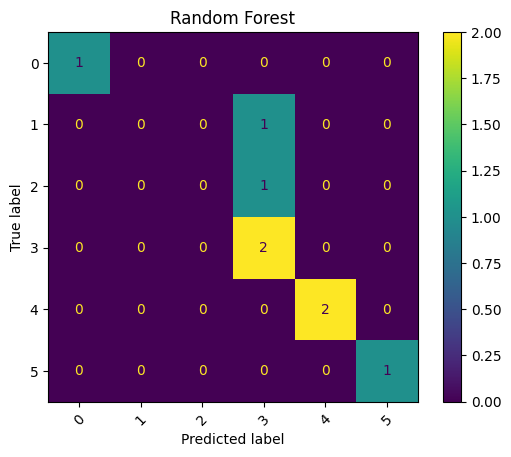


===== SVM RESULTS =====
Accuracy: 0.75
Macro F1: 0.611111111111111

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.50      1.00      0.67         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1

    accuracy                           0.75         8
   macro avg       0.58      0.67      0.61         8
weighted avg       0.62      0.75      0.67         8



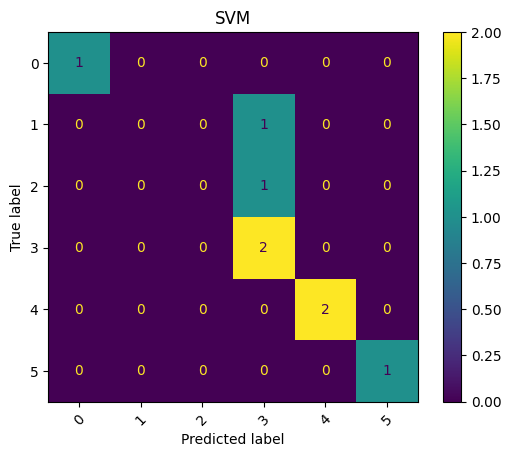


===== XGBoost RESULTS =====
Accuracy: 0.625
Macro F1: 0.38888888888888884

Classification Report:

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.50      1.00      0.67         2
           4       1.00      1.00      1.00         2
           5       0.00      0.00      0.00         1

    accuracy                           0.62         8
   macro avg       0.33      0.50      0.39         8
weighted avg       0.44      0.62      0.50         8



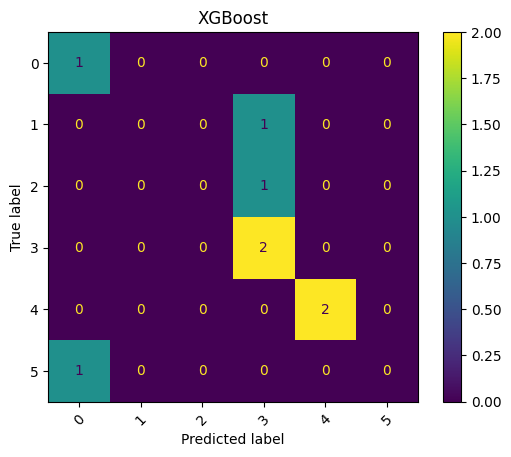

In [41]:
# run evaluations
rf_pred = evaluate(rf_model, X_test, y_test, "Random Forest")
svm_pred = evaluate(svm_model, X_test, y_test, "SVM")
xgb_pred = evaluate(xgb_model, X_test, y_test, "XGBoost")

In [ ]:
# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(rf_model, X, y, cv=cv)
svm_scores = cross_val_score(svm_model, X, y, cv=cv)
xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring="f1_macro")

print("\nRF CV Mean:", rf_scores.mean(), "Std:", rf_scores.std())
print("SVM CV Mean:", svm_scores.mean(), "Std:", svm_scores.std())
print("XGB CV Mean :", xgb_scores.mean(), "Std:", xgb_scores.std())


RF CV Mean: 0.7107142857142856 Std: 0.21735891506718483
SVM CV Mean: 0.8178571428571428 Std: 0.13238394994893313
XGB Mean F1: 0.5633333333333332 Std: 0.11587562510652166


In [43]:
scores = {
    "RF": rf_scores.mean(),
    "SVM": svm_scores.mean(),
    "XGB": xgb_scores.mean()
}

best_name = max(scores, key=scores.get)

best_model = {
    "RF": rf_model,
    "SVM": svm_model,
    "XGB": xgb_model
}[best_name]

print("\nBest Model Selected:", best_name)


Best Model Selected: SVM


In [44]:
# train final model
best_model.fit(X, y)

joblib.dump(best_model, "heart_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [45]:
# prediction function
def predict_heart(file_path):

    features = extract_features(file_path).reshape(1, -1)

    pred = best_model.predict(features)[0]

    return le.inverse_transform([pred])[0]